## PyTorch Tensors

In [1]:
import torch

In [ ]:
z = torch.zeros(5, 3)
print(z)
print(z.dtype)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
torch.float32


In [3]:
i = torch.ones(5, 3, dtype=torch.int16)
print(i)

tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]], dtype=torch.int16)


In [4]:
torch.manual_seed(1729)
r1 = torch.rand(2, 2)
print("A random tensor:")
print(r1)

r2 = torch.rand(2, 2)
print("\nA different random tensor:")
print(r2)

torch.manual_seed(1729)
r3 = torch.rand(2, 2)
print("\nShould match r1:")
print(r3)

A random tensor:
tensor([[0.3126, 0.3791],
        [0.3087, 0.0736]])

A different random tensor:
tensor([[0.4216, 0.0691],
        [0.2332, 0.4047]])

Should match r1:
tensor([[0.3126, 0.3791],
        [0.3087, 0.0736]])


In [5]:
ones = torch.ones(2, 3)
print(ones)

twos = torch.ones(2, 3) * 2
print(twos)

threes = ones + twos
print(threes)
print(threes.shape)

r1 = torch.rand(2, 3)
r2 = torch.rand(3, 2)
# r3 = r1 + r2

tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[2., 2., 2.],
        [2., 2., 2.]])
tensor([[3., 3., 3.],
        [3., 3., 3.]])
torch.Size([2, 3])


In [10]:
r = (torch.rand(2, 2) - 0.5) * 2
print('A random matrix, r:')
print(r)

print('\nAbsolute value of r:')
print(torch.abs(r))

print('\nInverse sine of r:')
print(torch.asin(r))

print('\nDeteminant of r:')
print(torch.det(r))
print('\nSingular value decomposition of r:')
print(torch.svd(r))

print('\nAverage and standard deviation of r:')
print(torch.std_mean(r))
print('\nMaximum value of r:')
print(torch.max(r))

A random matrix, r:
tensor([[ 0.8901, -0.5283],
        [-0.6041, -0.3345]])

Absolute value of r:
tensor([[0.8901, 0.5283],
        [0.6041, 0.3345]])

Inverse sine of r:
tensor([[ 1.0976, -0.5566],
        [-0.6487, -0.3411]])

Deteminant of r:
tensor(-0.6169)

Singular value decomposition of r:
torch.return_types.svd(
U=tensor([[-0.9043,  0.4268],
        [ 0.4268,  0.9043]]),
S=tensor([1.1143, 0.5536]),
V=tensor([[-0.9538, -0.3006],
        [ 0.3006, -0.9538]]))

Average and standard deviation of r:
(tensor(0.6988), tensor(-0.1442))

Maximum value of r:
tensor(0.8901)


## PyTorch Models

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [13]:
class LeNet(nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input image channel (black & white), 6 output channels, 5x5 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Max pooling over a (2, 2) window
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # If the size is a square you can only specify a single number
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

In [20]:
net = LeNet()
print(net)

input = torch.rand(1, 1, 32, 32)
print('\nImage batch shape:')
print(input.shape)

output = net(input)
print('\nRaw output:')
print(output)
print(output.shape)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Image batch shape:
torch.Size([1, 1, 32, 32])

Raw output:
tensor([[-0.0404, -0.0964, -0.0012, -0.1715, -0.1019, -0.0433, -0.0535,  0.0231,
         -0.0388,  0.1079]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])


In [25]:
from torchinfo import summary

summary(net, input_size=(1, 1, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
LeNet                                    [1, 10]                   --
├─Conv2d: 1-1                            [1, 6, 28, 28]            156
├─Conv2d: 1-2                            [1, 16, 10, 10]           2,416
├─Linear: 1-3                            [1, 120]                  48,120
├─Linear: 1-4                            [1, 84]                   10,164
├─Linear: 1-5                            [1, 10]                   850
Total params: 61,706
Trainable params: 61,706
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.42
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.25
Estimated Total Size (MB): 0.30

## Datasets and Dataloaders

In [26]:
# %matplotlib inline

import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ]
)

In [37]:
from torch.utils.data import ConcatDataset
from typing import cast, Tuple

transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

dataset: ConcatDataset[Tuple[torch.Tensor, int]] = ConcatDataset([trainset])
x = torch.stack([sample[0] for sample in dataset])

mean = torch.mean(x, dim=(0, 2, 3)); print(mean)
std = torch.std(x, dim=(0, 2, 3)); print(std)

tensor([0.4914, 0.4822, 0.4465])
tensor([0.2470, 0.2435, 0.2616])


In [38]:
trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

In [39]:
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True, num_workers=2
)

 frog   cat plane   cat


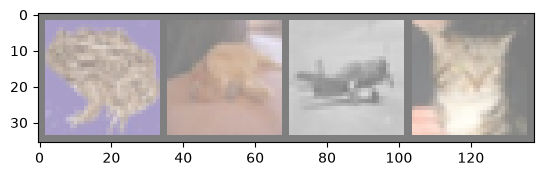

In [43]:
import matplotlib.pyplot as plt
import numpy as np

classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)


def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

## Training Your PyTorch Model

In [44]:
# %matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [45]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True, num_workers=2
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=4, shuffle=True, num_workers=2
)

classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

In [57]:
from typing import Any


class Net(nn.Module):
    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.conv1 = nn.Conv2d(3, 6, 5)  # input: (3,32,32)
        self.pool1 = nn.MaxPool2d(2, 2)  # input: (6,28,28)
        self.conv2 = nn.Conv2d(6, 16, 5)  # input: (6,14,14)
        self.pool2 = self.pool1  # input: (16,10,10)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # input 16*5*5
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [53]:
from torchinfo import summary

summary(net, (1, 3, 32, 32), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Net                                      [1, 3, 32, 32]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 3, 32, 32]            [1, 6, 28, 28]            456
├─MaxPool2d: 1-2                         [1, 6, 28, 28]            [1, 6, 14, 14]            --
├─Conv2d: 1-3                            [1, 6, 14, 14]            [1, 16, 10, 10]           2,416
├─MaxPool2d: 1-4                         [1, 16, 10, 10]           [1, 16, 5, 5]             --
├─Linear: 1-5                            [1, 400]                  [1, 120]                  48,120
├─Linear: 1-6                            [1, 120]                  [1, 84]                   10,164
├─Linear: 1-7                            [1, 84]                   [1, 10]                   850
Total params: 62,006
Trainable params: 62,006
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.66
Input si

In [58]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [59]:
for epoch in range(2):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(trainloader, 0):
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print("[%d, %5d] loss: %.3f" % (epoch + 1, i, running_loss / 2000))
            running_loss = 0.0

print("Finished Trainning")

[1,  1999] loss: 2.155
[1,  3999] loss: 1.819
[1,  5999] loss: 1.631
[1,  7999] loss: 1.550
[1,  9999] loss: 1.481
[1, 11999] loss: 1.429
[2,  1999] loss: 1.363
[2,  3999] loss: 1.320
[2,  5999] loss: 1.322
[2,  7999] loss: 1.278
[2,  9999] loss: 1.273
[2, 11999] loss: 1.241
Finished Trainning


In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in testloader:
        outputs = net(inputs)
        _, predicted = torch.max(outputs.detach(), 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(
    "Accuracy of the network on the 10000 test images: %d %%" % (100 * correct / total)
)

Accuracy of the network on the 10000 test images: 55 %
